In [32]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
from STX3KO_analyses import utilities_ES as u_es
from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [91]:
def get_cell_orders(mouse, session_deets, days, match_inds):
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
            
    
    cell_order = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets,tuple):
            roi_inds = []
            for _deets in deets:
                roi_inds.append(_deets['ravel_ind'])
            print(roi_inds)
            mapping = u.common_rois(match_inds, roi_inds)
            
            cell_order.append(mapping[0,:].tolist())
        else:
            cell_order.append([])
    return cell_order

def common_rois_adjust(mouse, days):
    if mouse in ctrl_mice:
        session_deets = stx.ymaze_sess_deets.CTRL_sessions[mouse]
    else:
        session_deets = stx.ymaze_sess_deets.KO_sessions[mouse]
    
    
    ravel_inds = []
    day_inds = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets, tuple):
            for _deets in deets:
                ravel_inds.append(_deets['ravel_ind'])
                day_inds.append(day)
        else:
            ravel_inds.append(deets['ravel_ind'])
            day_inds.append(day)

    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
        match_inds = dill.load(file)
    

    common_roi_mapping = u.common_rois(match_inds, ravel_inds)
    c_rows = []
    for i, d in enumerate(day_inds):
        if d != day_inds[i-1]:
            c_rows.append(i)
    
    common_roi_mapping = common_roi_mapping[c_rows,:]
    cell_order = get_cell_orders(mouse,session_deets, days, match_inds)

    roi_mapping_adj = np.zeros(common_roi_mapping.shape)
    c_cols = []
    for row, order in enumerate(cell_order):
        croi = common_roi_mapping[row,:]

        if len(order)==0:
            roi_mapping_adj[row,:] = croi
        else:
            for col, _c in enumerate(croi):
                match = np.argwhere(order==_c)
                if len(match)>0:
                    c_cols.append(col)
                    roi_mapping_adj[row,col]=match[0][0]
                    
                    
    if len(c_cols) !=0:
        roi_mapping_adj = roi_mapping_adj[:,c_cols]
    return roi_mapping_adj.astype(int)


def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):

        corr_dict[react_day] = {}

        for tt_corr_day in range(react_day,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = common_rois_adjust(mouse, days)


                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)

                # trial matrix 
                with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                    hse_tt_corr = pickle.load(file)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                
                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                
                trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

                for cell in range(trial_mat.shape[-1]):
                    corr_mat[:,:,cell] = np.corrcoef(trial_mat[:,:,cell])

                for cell in range(corr_mat.shape[-1]):
                    _mat = corr_mat[:, :,cell]
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=r
                
    return corr_dict

def predict_across_day_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    # common_roi_mapping = common_rois_adjust(mouse, np.arange(6))
    for react_day in range(5):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]

            common_roi_mapping = common_rois_adjust(mouse, days)
            


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            
            
            # trial matrix 
            with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                hse_fut = pickle.load(file)
              
            
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                
                if key == 'fam':
                    trial_mask_react = hse_react.trial_info['LR']!=hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']!=hse_fut.novel_arm
                else:
                    trial_mask_react = hse_react.trial_info['LR']==hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']==hse_fut.novel_arm

                tmat_react = np.nanmean(hse_react.trial_mat[trial_mask_react, :, :][:, :, common_roi_mapping[0,:]], axis=0)
                tmat_fut = np.nanmean(hse_fut.trial_mat[trial_mask_fut, :, :][:, :, common_roi_mapping[1,:]], axis=0)

                tmat_react[np.isnan(tmat_react)]=0
                tmat_fut[np.isnan(tmat_fut)]=0
                

                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                

                
                cell_r, _ = sp.stats.pearsonr(tmat_react, tmat_fut, axis=0)

                


                corr_dict[react_day][tt_corr_day][key]['cell_corr']=cell_r
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=hse_r
                # except:
                #     corr_dict[react_day][tt_corr_day][key]['activated']=np.nan
                #     corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nan
                    
    return corr_dict


In [105]:
corr_dict = predict_across_day_stability(ctrl_mice[0])

4467331.1


/tmp/ipykernel_44315/1178253329.py:190: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
/tmp/ipykernel_44315/1178253329.py:190: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
/tmp/ipykernel_44315/1178253329.py:190: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
/tmp/ipykernel_44315/1178253329.py:190: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
/tmp/ipykernel_44315/117

SignificanceResult(statistic=np.float64(0.037094773782155165), pvalue=np.float64(0.47151230674964073))


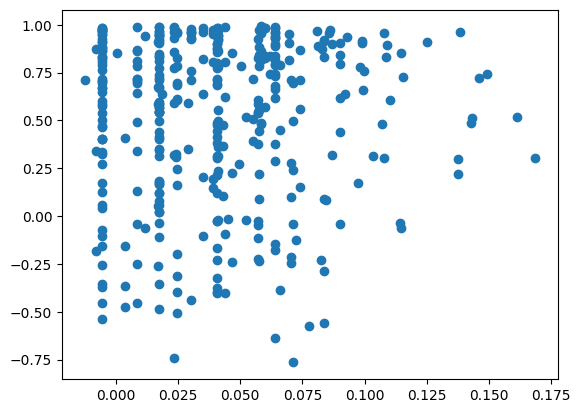

In [110]:
fig, ax = plt.subplots()
ttday = 3
hseday = 1

hse_corr = corr_dict[hseday][ttday]['nov']['hse_corr']
tt_corr =  corr_dict[hseday][ttday]['nov']['cell_corr']
ax.scatter(hse_corr,tt_corr)
nanmask = np.isnan(hse_corr*tt_corr)
print(sp.stats.spearmanr(hse_corr[~nanmask],tt_corr[~nanmask]))

In [7]:
#  load single replay session
cond_key = 'ctrl'
mouse = ctrl_mice[2]
day=2

with open(hse_dict[cond_key][day][mouse], 'rb') as file:
    hse = pickle.load(file)


/tmp/ipykernel_44315/2934518741.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse.activation_mask.sum(axis=0)[np.newaxis,hse.post_reward_bool>0],spks_ledge[:,hse.post_reward_bool>0], axis=-1)


[[ 1.         -0.83255802 -0.56931043 -0.31240202 -0.62115443  0.23651202
   0.2650433  -0.59833078  0.1470983  -0.4743586   0.70048997  0.01027596
  -0.26709065 -0.01975718  0.01424911 -0.43344236 -0.33316859 -0.13559541
   0.94545644 -0.44341076]
 [-0.83255802  1.          0.53251352  0.07840336  0.43929303 -0.34642046
  -0.39619595  0.69060429 -0.16904494  0.29128207 -0.72808433 -0.0783378
   0.23789169 -0.01179561 -0.02965857  0.55500388  0.27197575 -0.00230879
  -0.90460557  0.39354115]
 [-0.56931043  0.53251352  1.          0.29287272  0.06012932  0.00873388
  -0.09506257  0.49188151 -0.11082794  0.2373627  -0.26952606 -0.04909987
   0.61106915 -0.12087293  0.12326204  0.09026689  0.09033884  0.21617516
  -0.49301609  0.11361174]
 [-0.31240202  0.07840336  0.29287272  1.          0.4544213   0.44487205
   0.21658689  0.28321802 -0.04213645  0.52736912  0.04913724 -0.14898721
   0.32054976 -0.04560236  0.4215293  -0.25719881  0.42224286  0.46770369
  -0.10274346 -0.05397614]
 [-0.

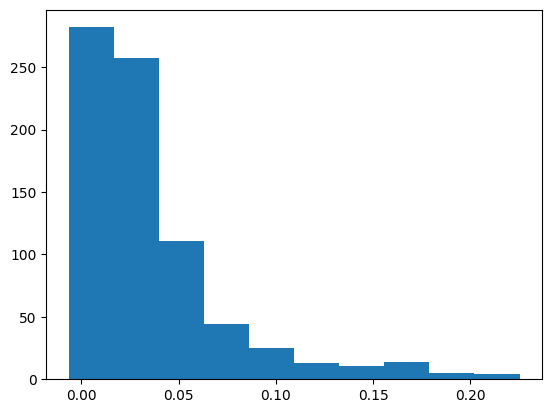

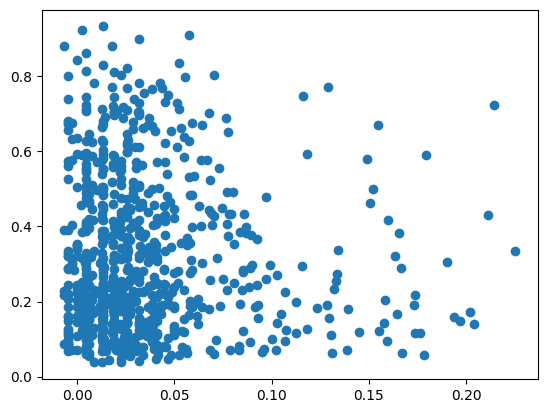

In [31]:
spks_ledge = 1*(np.diff(1.*(hse.spks_th>0),prepend=0,axis=-1)>0)


r,_ = sp.stats.pearsonr(hse.activation_mask.sum(axis=0)[np.newaxis,hse.post_reward_bool>0],spks_ledge[:,hse.post_reward_bool>0], axis=-1)

fig, ax = plt.subplots()
ax.hist(r)


nov_trial_mask = hse.trial_info['LR'] == hse.novel_arm

nov_trial_mat = hse.trial_mat[nov_trial_mask,:,:]
nov_trial_mat[np.isnan(nov_trial_mat)]=0
nov_corr_mat = np.zeros([nov_trial_mat.shape[0], nov_trial_mat.shape[0], nov_trial_mat.shape[-1]])

for cell in range(nov_trial_mat.shape[-1]):
    nov_corr_mat[:,:,cell] = np.corrcoef(nov_trial_mat[:,:,cell])

fig, ax = plt.subplots()
ax.scatter(r, nov_corr_mat.mean(axis=0).mean(axis=0))
print(nov_corr_mat[:,:,0])


In [ ]:
#  concatenate all postreward reactivation